In [2]:
import pandas as pd
import numpy as np
from final_project_d200.data import read_data
from final_project_d200.preprocessing import add_features_responders, downsample, NUM_FEATURES, CAT_FEATURES, TARGET_COL, TARGET_COLS_PRE
from final_project_d200.modeling import train_mdn, pretrain_mdn, run_mdn_config, train_mdn_crps, train_mdn_crps_and_nll
from final_project_d200.evaluation import (
    compute_mdn_nll, compute_mean_crps_mdn, get_predicted_parameters, 
    compute_pretrain_loss_components, compute_pretrain_loss,
    read_grid_search_results, write_grid_search_results,
    calculate_normal_nll, compute_mean_crps_gaussian
)
from final_project_d200.plotting import (
    plot_predicted_parameters, plot_pit, plot_mdns_vs_gbt_vol_medoid,
    plot_train_and_val_loss
)
# from final_project_d200.options import simula
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from collections import OrderedDict
from torch.utils.data import DataLoader, TensorDataset
import scipy.stats as stats
import itertools
import copy
from pathlib import Path

### Load Data

In [3]:
df = read_data("btc_with_gbt_preds")
df.head()

,split,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,...,quote_volume_pct_change,past_180m_vol,past_720m_vol,past_1440m_vol,past_10080m_vol,past_43200m_vol,past_50m_span_ewm_vol,past_50m_vol_pct_change,event_code,gbt_future_30m_mean_sq_ret_pred
43200,train,2023-11-30 19:00:00 ET,37723.97,37744.72,37722.73,37738.91,34.53633,2023-11-30 19:00:59 ET,1.303099e+06,1119,...,0.061855,0.175818,0.277380,0.260482,0.320534,0.412684,0.185884,-0.099284,NONE,9.346555e-08
43201,train,2023-11-30 19:01:00 ET,37738.91,37738.91,37723.72,37723.72,12.71120,2023-11-30 19:01:59 ET,4.796356e+05,667,...,0.096078,0.176291,0.277533,0.260587,0.320546,0.412684,0.190869,-0.081458,NONE,9.226979e-08
43202,train,2023-11-30 19:02:00 ET,37723.72,37723.73,37699.57,37699.57,33.22694,2023-11-30 19:02:59 ET,1.252938e+06,956,...,0.012599,0.177571,0.277139,0.260694,0.320557,0.412678,0.195810,-0.067271,NONE,9.546778e-08
43203,train,2023-11-30 19:03:00 ET,37699.58,37699.58,37699.57,37699.57,6.89939,2023-11-30 19:03:59 ET,2.601041e+05,341,...,0.093164,0.180828,0.277650,0.260867,0.320590,0.412682,0.212787,-0.013871,NONE,1.121719e-07
43204,train,2023-11-30 19:04:00 ET,37699.57,37699.58,37688.27,37688.35,14.22495,2023-11-30 19:04:59 ET,5.362203e+05,476,...,-0.004551,0.179834,0.276626,0.260862,0.320585,0.412672,0.208573,-0.042709,NONE,9.886201e-08


Note that data is pre-split into train/val/test, and we already have predictions from my best GBT model. Plenty of preprocessing has already been done.

### Part 2: Mixed Density Network
Now, I will construct a feature set and training/validation pipeline to create the best MDN to predict future distributions of returns.

In [4]:
df = read_data("btc_with_gbt_preds")
df = add_features_responders(df)

In [5]:
cols = NUM_FEATURES + CAT_FEATURES + [TARGET_COL] + TARGET_COLS_PRE


df_train = downsample(df.query("split == 'train'"), set([0, 30])).dropna(subset=cols)
df_val = downsample(df.query("split == 'val'"), set([0, 30])).dropna(subset=cols)
df_test = downsample(df.query("split == 'test'"), set([0, 30])).dropna(subset=cols)

# Make numerical feature tensors
X_train_num = df_train[NUM_FEATURES].to_numpy(dtype=np.float32)
X_val_num = df_val[NUM_FEATURES].to_numpy(dtype=np.float32)
X_test_num = df_test[NUM_FEATURES].to_numpy(dtype=np.float32)

# Future 30m return targets
y_train = df_train[TARGET_COL].to_numpy(dtype=np.float32)
y_val = df_val[TARGET_COL].to_numpy(dtype=np.float32)
y_test = df_test[TARGET_COL].to_numpy(dtype=np.float32)

# Extract pretrain targets, to be used for transfer learning
y_train_pre = df_train[TARGET_COLS_PRE].to_numpy(dtype=np.float32)
y_val_pre = df_val[TARGET_COLS_PRE].to_numpy(dtype=np.float32)

# Scale features, train scaler on train set
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_val_num = scaler.transform(X_val_num)
X_test_num = scaler.transform(X_test_num)

X_train_num = torch.tensor(X_train_num, dtype=torch.float32)
X_val_num = torch.tensor(X_val_num, dtype=torch.float32)
X_test_num = torch.tensor(X_test_num, dtype=torch.float32)

# Make categorical feature tensors
X_train_cat = df_train[CAT_FEATURES]
X_val_cat = df_val[CAT_FEATURES]
X_test_cat = df_test[CAT_FEATURES]

# Encode categoricals
encoder = OneHotEncoder(sparse_output=False, handle_unknown="error")
X_train_cat = encoder.fit_transform(X_train_cat)
X_val_cat = encoder.transform(X_val_cat)
X_test_cat = encoder.transform(X_test_cat)

X_train_cat = torch.tensor(X_train_cat, dtype=torch.float32)
X_val_cat = torch.tensor(X_val_cat, dtype=torch.float32)
X_test_cat = torch.tensor(X_test_cat, dtype=torch.float32)

# Combine categoricals + turn into tensors
X_train = torch.cat([X_train_num, X_train_cat], dim=1)
X_val = torch.cat([X_val_num, X_val_cat], dim=1)
X_test = torch.cat([X_test_num, X_test_cat], dim=1)

# Convert targets to tensors
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

y_train_pre = torch.tensor(y_train_pre, dtype=torch.float32)
y_val_pre = torch.tensor(y_val_pre, dtype=torch.float32)

# Turn into TensorDataset for DataLoader
train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)
test_data = TensorDataset(X_test, y_test)

# Do the same for transfer data
train_data_pre = TensorDataset(X_train, y_train_pre)
val_data_pre = TensorDataset(X_val, y_val_pre)

device = "cuda" if torch.cuda.is_available() else "cpu"

First model: hidden layers directly to output layer for mixed density parameters.

In [6]:
# Create MDN

class MDN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, hidden_layers=2, n_components=3, mean_zero=False,
                 dropout=0.0, feature_dropout=0.0):
        super().__init__()

        hidden_layer_list = []
        for i in range(hidden_layers):
            hidden_layer_list.append((f"linear{i}", nn.Linear(hidden_dim, hidden_dim)))
            hidden_layer_list.append((f"relu{i}", nn.ReLU()))
            hidden_layer_list.append((f"dropout{i}", nn.Dropout(dropout)))


        self.net = nn.Sequential(OrderedDict([
            ("feature_dropout", nn.Dropout(feature_dropout)),
            ("input", nn.Linear(input_dim, hidden_dim)),
            ("relu_input", nn.ReLU()),
            ("dropout_input", nn.Dropout(dropout))] + hidden_layer_list
        ))

        self.mixture_weights = nn.Linear(hidden_dim, n_components)
        if not mean_zero:
            self.means = nn.Linear(hidden_dim, n_components)
        else:
            self.means = None
        self.scales = nn.Linear(hidden_dim, n_components)

        self.n_components = n_components

    def forward(self, x):
        out = self.net(x)

        mixture_weights = self.mixture_weights(out)
        mixture_probs = F.softmax(mixture_weights, dim=1)
        
        if self.means is not None:
            uncentered_means = self.means(out)
            weighted_mean = (uncentered_means * mixture_probs).sum(dim=1, keepdim=True)
            means = uncentered_means - weighted_mean
        else:
            means = torch.zeros(out.shape[0], self.n_components, device=out.device)

        scales = F.softplus(self.scales(out)) + 1e-6

        return mixture_probs, means, scales
    
def build_mdn(params: dict[str, Any], input_dim: int) -> MDN:
    """
    Function used to build MDN in grid search loops.

    Parameters
    ----------
    params : dict[str, Any]
        Dictionary containing all necessary hyperparams.
    input_dim : int
        Input dimension to MDN.

    Returns
    -------
    MDN
        Instantiated MDN.
    """
    return MDN(
        input_dim=input_dim,
        hidden_dim=params["hidden_dim"],
        hidden_layers=params["hidden_layers"],
        n_components=params["n_components"],
        mean_zero=params["mean_zero"],
        dropout=params["dropout"],
        feature_dropout=params["feature_dropout"],
    )

In [8]:
param_grid = {
    "batch_size": [128],
    "hidden_dim": [16],
    "hidden_layers": [3],
    "n_components": [5],
    "mean_zero": [True],
    "dropout": [0],
    "feature_dropout": [0.1],
    "lr": [1e-4],
    "weight_decay": [0],
    "lambda_mean": [0]
}

keys = param_grid.keys()
values = param_grid.values()

rows = []
combos = list(itertools.product(*values))

for i, combo in enumerate(combos, start=1):

    params = dict(zip(keys, combo))
    print(f"testing {params}, {i}/{len(combos)}")

    best_val_nll, avg_train_nll_near_optimum, avg_val_nll_near_optimum, avg_val_crps_near_optimum, num_epochs = run_mdn_config(
        build_mdn, params, X_train, 
        y_train, X_val, y_val, epochs=20
    )

    rows.append({
        "params": tuple(sorted(params.items())),
        "best_val_nll": best_val_nll,
        "avg_train_nll_near_optimum": avg_train_nll_near_optimum,
        "avg_val_nll_near_optimum": avg_val_nll_near_optimum,
        "avg_val_crps_near_optimum": avg_val_crps_near_optimum,
    })

    print(f"Best Val NLL: {best_val_nll}, took {num_epochs} epochs")

df_results = pd.DataFrame(rows)


testing {'batch_size': 128, 'hidden_dim': 16, 'hidden_layers': 3, 'n_components': 5, 'mean_zero': True, 'dropout': 0, 'feature_dropout': 0.1, 'lr': 0.0001, 'weight_decay': 0, 'lambda_mean': 0}, 1/1
Best Val NLL: -4.528125286102295, took 20 epochs


In [9]:
pd.options.display.max_colwidth = None
display(df_results.sort_values(by="best_val_nll", ascending=True))

,params,best_val_nll,avg_train_nll_near_optimum,avg_val_nll_near_optimum,avg_val_crps_near_optimum
0,"((batch_size, 128), (dropout, 0), (feature_dropout, 0.1), (hidden_dim, 16), (hidden_layers, 3), (lambda_mean, 0), (lr, 0.0001), (mean_zero, True), (n_components, 5), (weight_decay, 0))",-4.528125,-4.332555,-4.505477,0.001659


In [7]:
write_grid_search_results(df_results)


Appended results to hyperparams.csv


,params,best_val_nll,avg_val_nll_last_20,avg_train_nll_last_20,avg_val_crps_last_20
0,"((batch_size, 128), (dropout, 0), (feature_dropout, 0.1), (hidden_dim, 16), (hidden_layers, 3), (lambda_mean, 0), (lr, 0.0001), (mean_zero, True), (n_components, 5), (weight_decay, 0))",-4.571615,-4.567982,-4.413198,0.001611


In [46]:
df_all_results = read_grid_search_results()

pd.options.display.max_colwidth = None
display(df_all_results.sort_values(by="avg_val_nll_last_20", ascending=True))

,params,best_val_nll,avg_val_nll_last_20,avg_train_nll_last_20,avg_val_crps_last_20
25,"(('batch_size', 128), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.573200,-4.571742,-4.413239,0.001610
24,"(('batch_size', 128), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.573100,-4.571230,-4.410264,0.001609
16,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 8), ('hidden_layers', 4), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.572700,-4.570869,-4.411037,0.001610
5,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.573600,-4.570648,-4.413942,0.001609
30,"(('batch_size', 128), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.571721,-4.570474,-4.416370,0.001610
27,"(('batch_size', 128), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.572300,-4.570264,-4.414996,0.001610
20,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 8), ('hidden_layers', 5), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.571700,-4.570139,-4.410198,0.001609
1,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.05), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.572100,-4.569923,-4.415483,0.001611
22,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 16), ('hidden_layers', 3), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.573200,-4.569559,-4.413073,0.001611
19,"(('batch_size', 32), ('dropout', 0), ('feature_dropout', 0.1), ('hidden_dim', 4), ('hidden_layers', 5), ('lambda_mean', 0), ('lr', 0.0001), ('mean_zero', True), ('n_components', 5), ('weight_decay', 0))",-4.571500,-4.569523,-4.406781,0.001609


Did plenty of grid search: shallow nets 3-4 deep performed best. Settled on component selection for 3x16, 4 or 5 components performed best. Below is a full training loop, written in its entirety.

In [6]:
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

model = MDN(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    n_components=5,
    mean_zero=True,
    feature_dropout=0.1
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=0)

epochs = 300
early_stopping_patience = 100

results = []
best_val_nll = np.inf
last_improvement = 0
best_state_dict = None

print_frequency = 20

for t in range(1, epochs + 1):
    epoch_loss = train_mdn(model, train_loader, optimizer)
    epoch_train_nll = compute_mdn_nll(model, train_loader)
    epoch_val_nll = compute_mdn_nll(model, val_loader)
    epoch_val_crps = compute_mean_crps_mdn(model, val_loader)

    if epoch_val_nll < best_val_nll:
        best_val_nll = epoch_val_nll
        last_improvement = t
        best_state_dict = copy.deepcopy(model.state_dict())

    if (t % print_frequency) == 0:
        print(f"Epoch {t}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss:.2f}, training nll: {epoch_train_nll}, val nll: {epoch_val_nll}, val crps: {epoch_val_crps}\n")

    results.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
    
    if t - last_improvement >= early_stopping_patience:
        break

best_idx = max(0, last_improvement - 1)

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

results = np.array(results)
val_nlls = results[:, 2]
left = max(0, best_idx - 10)
right = min(len(val_nlls), best_idx + 3)
local_mean_val_nll = float(np.mean(val_nlls[left:right]))
print(f"Best val nll: {best_val_nll}, local mean vall nll: {local_mean_val_nll:.6f}")


Epoch 20/300
-------------------------------
Loss: -4.31, training nll: -4.367194175720215, val nll: -4.536890983581543, val crps: 0.0016357098147488864

Epoch 40/300
-------------------------------
Loss: -4.36, training nll: -4.394161701202393, val nll: -4.56271505355835, val crps: 0.0016136135386375502

Epoch 60/300
-------------------------------
Loss: -4.38, training nll: -4.401076793670654, val nll: -4.566797256469727, val crps: 0.0016113634304898454

Epoch 80/300
-------------------------------
Loss: -4.39, training nll: -4.40463924407959, val nll: -4.567813873291016, val crps: 0.0016107984292131417

Epoch 100/300
-------------------------------
Loss: -4.39, training nll: -4.407861232757568, val nll: -4.569536209106445, val crps: 0.0016100798346220403

Epoch 120/300
-------------------------------
Loss: -4.40, training nll: -4.406888961791992, val nll: -4.566224098205566, val crps: 0.0016114222582354822

Epoch 140/300
-------------------------------
Loss: -4.40, training nll: -4.

In [ ]:
# Make sure results directory exists - as it should from grid search
torch.save(model.state_dict(), "../results/original_model.pt")

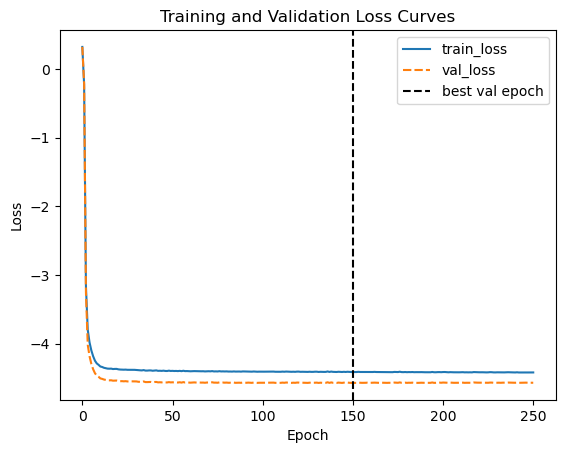

In [7]:
ax = plot_train_and_val_loss(np.array(results))

In [355]:
df

,split,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,...,future_30m_mean_abs_ret,future_5m_mean_sq_ret,future_15m_mean_sq_ret,future_30m_mean_sq_ret,future_30m_neutral_up_down,past_5m_abs_ret,past_30m_abs_ret,past_60m_abs_ret,past_120m_abs_ret,day_of_week
43200,train,2023-11-30 19:00:00 ET,37723.97,37744.72,37722.73,37738.91,34.53633,2023-11-30 19:00:59 ET,1.303099e+06,1119,...,0.000230,1.634154e-07,1.151254e-07,8.599236e-08,0,NaN,NaN,NaN,NaN,3
43201,train,2023-11-30 19:01:00 ET,37738.91,37738.91,37723.72,37723.72,12.71120,2023-11-30 19:01:59 ET,4.796356e+05,667,...,0.000220,1.434519e-07,1.087317e-07,8.103961e-08,0,NaN,NaN,NaN,NaN,3
43202,train,2023-11-30 19:02:00 ET,37723.72,37723.73,37699.57,37699.57,33.22694,2023-11-30 19:02:59 ET,1.252938e+06,956,...,0.000220,1.110502e-07,9.808543e-08,8.121653e-08,0,NaN,NaN,NaN,NaN,3
43203,train,2023-11-30 19:03:00 ET,37699.58,37699.58,37699.57,37699.57,6.89939,2023-11-30 19:03:59 ET,2.601041e+05,341,...,0.000212,4.045043e-08,8.657648e-08,7.281127e-08,0,NaN,NaN,NaN,NaN,3
43204,train,2023-11-30 19:04:00 ET,37699.57,37699.58,37688.27,37688.35,14.22495,2023-11-30 19:04:59 ET,5.362203e+05,476,...,0.000219,4.116323e-08,9.522848e-08,7.437664e-08,1,NaN,NaN,NaN,NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120145,test,2025-12-17 16:05:00 ET,86003.26,86027.13,85994.15,86014.78,6.02012,2025-12-17 16:05:59 ET,5.177601e+05,2783,...,NaN,NaN,NaN,NaN,1,0.001314,0.000027,0.001916,0.004798,2
1120146,test,2025-12-17 16:06:00 ET,86014.78,86014.78,85999.98,85999.98,1.70505,2025-12-17 16:06:59 ET,1.466470e+05,1075,...,NaN,NaN,NaN,NaN,1,0.001079,0.000291,0.003559,0.004791,2
1120147,test,2025-12-17 16:07:00 ET,85999.98,85999.99,85959.91,85961.49,2.15626,2025-12-17 16:07:59 ET,1.853872e+05,1682,...,NaN,NaN,NaN,NaN,1,0.001208,0.000581,0.003421,0.004892,2
1120148,test,2025-12-17 16:08:00 ET,85961.50,85972.71,85947.25,85955.41,2.53866,2025-12-17 16:08:59 ET,2.182114e+05,1413,...,NaN,NaN,NaN,NaN,1,0.000392,0.000882,0.002590,0.004811,2


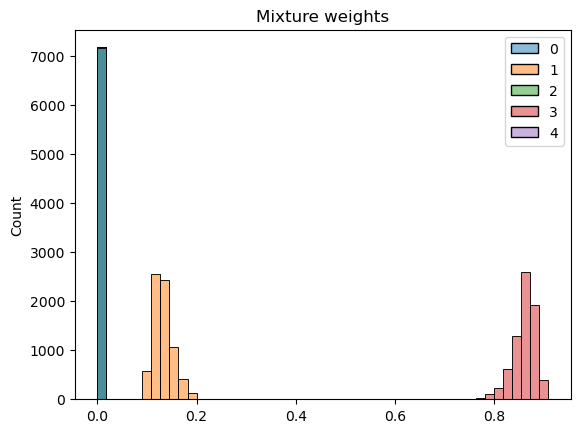

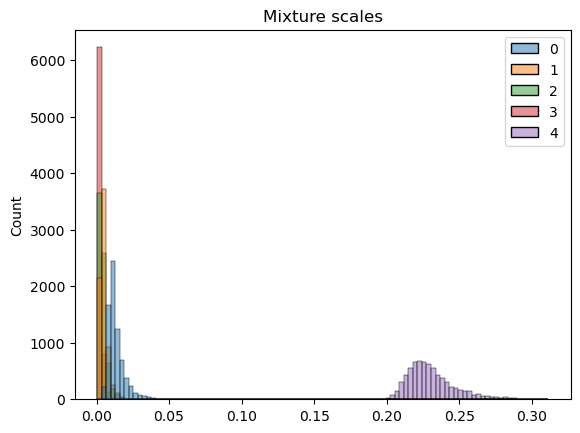

In [8]:
val_weights, val_means, val_scales = (p.numpy() for p in get_predicted_parameters(model, val_loader))
ax = sns.histplot(val_weights, bins=50)
ax.set_title("Mixture weights")
plt.show()

# ax = sns.histplot(val_means, bins=50)
# ax.set_title("Mixture means")
# plt.show()

ax = sns.histplot(val_scales, bins=100)
ax.set_title("Mixture scales")
plt.show()

### Transfer Learning

In [7]:
class MDNBackbone(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, hidden_layers=2, dropout=0.0, feature_dropout=0.0):
        super().__init__()

        hidden_layer_list = []
        for i in range(hidden_layers):
            hidden_layer_list.append((f"linear{i}", nn.Linear(hidden_dim, hidden_dim)))
            hidden_layer_list.append((f"relu{i}", nn.ReLU()))
            hidden_layer_list.append((f"dropout{i}", nn.Dropout(dropout)))


        self.net = nn.Sequential(OrderedDict([
            ("feature_dropout", nn.Dropout(feature_dropout)),
            ("input", nn.Linear(input_dim, hidden_dim)),
            ("relu_input", nn.ReLU()),
            ("dropout_input", nn.Dropout(dropout))] + hidden_layer_list
        ))

        self.hidden_dim = hidden_dim

    def forward(self, x):
        return self.net(x)
    
    
class MDNPretrain(nn.Module):
    def __init__(self, backbone,):
        super().__init__()
        self.backbone = backbone
        hidden_dim = backbone.hidden_dim

        self.vol_5_prediction = nn.Linear(hidden_dim, 1)
        self.vol_15_prediction = nn.Linear(hidden_dim, 1)
        self.vol_30_prediction = nn.Linear(hidden_dim, 1)
        self.mean_abs_30_prediction = nn.Linear(hidden_dim, 1)
        self.move_direction = nn.Linear(hidden_dim, 3)

    def forward(self, x):
        x_backbone = self.backbone(x)

        return (self.vol_5_prediction(x_backbone), self.vol_15_prediction(x_backbone),
                self.vol_30_prediction(x_backbone), self.mean_abs_30_prediction(x_backbone),
                self.move_direction(x_backbone))


class MDNFinalLayer(nn.Module):
    def __init__(self, backbone, n_components=3, mean_zero=True):
        super().__init__()
        self.backbone = backbone
        self.hidden_dim = backbone.hidden_dim

        self.mixture_weights = nn.Linear(self.hidden_dim, n_components)
        if not mean_zero:
            self.means = nn.Linear(self.hidden_dim, n_components)
        else:
            self.means = None
        self.scales = nn.Linear(self.hidden_dim, n_components)

        self.n_components = n_components

    def forward(self, x):
        out = self.backbone(x)

        mixture_weights = self.mixture_weights(out)
        mixture_probs = F.softmax(mixture_weights, dim=1)

        if self.means is not None:
            uncentered_means = self.means(out)
            weighted_mean = (uncentered_means * mixture_probs).sum(dim=1, keepdim=True)
            means = uncentered_means - weighted_mean
        else:
            means = torch.zeros(out.shape[0], self.n_components, device=out.device)

        scales = F.softplus(self.scales(out)) + 1e-6

        return mixture_probs, means, scales

In [313]:
train_loader_pre = DataLoader(train_data_pre, batch_size=256, shuffle=True)
val_loader_pre = DataLoader(val_data_pre, batch_size=256, shuffle=False)

backbone = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    feature_dropout=0.05
)

pretrain_model = MDNPretrain(
    backbone=backbone
)

optimizer = torch.optim.Adam(pretrain_model.parameters(), lr=5e-4, weight_decay=2e-5)
loss_fn = F.huber_loss

epochs = 500
early_stopping_patience = 20

pretrain_results = []
best_val_loss = np.inf
last_improvement = 0
best_state_dict_pretrain = None

print_frequency = 20
print_loss_components = False

for t in range(1, epochs + 1):
    epoch_loss = pretrain_mdn(pretrain_model, train_loader_pre, optimizer, loss_fn)
    epoch_val_loss = compute_pretrain_loss(pretrain_model, val_loader_pre, loss_fn)
    epoch_train_loss = compute_pretrain_loss(pretrain_model, train_loader_pre, loss_fn)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        last_improvement = t
        best_state_dict_pretrain = copy.deepcopy(pretrain_model.state_dict())

    if t % print_frequency == 0:
        print(f"Epoch {t}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss}, training loss: {epoch_train_loss}, val loss: {epoch_val_loss}\n")

        if print_loss_components:
            vol5_l, vol15_l, vol30_l, abs30_l, direction_l = compute_pretrain_loss_components(
                pretrain_model, val_loader_pre, loss_fn
            )
            print(f"vol5: {vol5_l}, vol15: {vol15_l}, vol30: {vol30_l}, abs30: {abs30_l}, direction: {direction_l}\n")

    pretrain_results.append([epoch_loss, epoch_train_loss, epoch_val_loss])
    
    if t - last_improvement >= early_stopping_patience:
        print(f"Best val loss: {best_val_loss}")
        break

if best_state_dict_pretrain is not None:
    pretrain_model.load_state_dict(best_state_dict_pretrain)
    
pretrain_results = np.array(pretrain_results)


Epoch 20/500
-------------------------------
Loss: 0.005316850121187813, training loss: 0.005308013020517833, val loss: 0.005277444238717787

Epoch 40/500
-------------------------------
Loss: 0.005280543458374107, training loss: 0.005270175707774212, val loss: 0.005249877592105315

Epoch 60/500
-------------------------------
Loss: 0.0052670997293556435, training loss: 0.005263699558362874, val loss: 0.0052438673883990995

Epoch 80/500
-------------------------------
Loss: 0.005259926293921822, training loss: 0.005258099499807581, val loss: 0.005254609455038103

Best val loss: 0.005242028093773175


In [314]:
torch.save(pretrain_model.state_dict(), "../results/pretrain_model.pt")

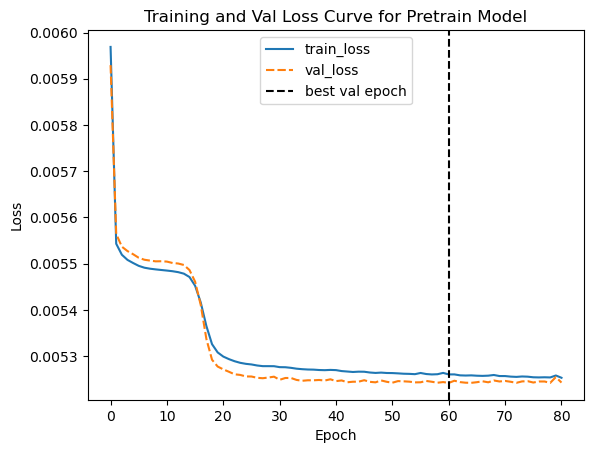

In [315]:
ax = plot_train_and_val_loss(np.array(pretrain_results), title="Training and Val Loss Curve for Pretrain Model")

In [ ]:
# Load best pretrain model
backbone = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    feature_dropout=0.025
)

pretrain_model = MDNPretrain(
    backbone=backbone
)

pretrain_model.load_state_dict(torch.load("../results/pretrain_model.pt", map_location="cpu"))

# Full training loop
train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

transfer_model_ret = MDNFinalLayer(backbone, n_components=5, mean_zero=False)

if transfer_model_ret.means is not None:
    # Initialize mean weights to 0
    torch.nn.init.zeros_(transfer_model_ret.means.weight)
    torch.nn.init.zeros_(transfer_model_ret.means.bias)
        
    # freeze backbone if I want
    for param in transfer_model_ret.backbone.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam(
        [
            {"params": transfer_model_ret.backbone.parameters(), "lr": 1e-5},
            {"params": transfer_model_ret.mixture_weights.parameters(), "lr": 1e-4},
            {"params": transfer_model_ret.scales.parameters(), "lr": 1e-4},
            {"params": transfer_model_ret.means.parameters(), "lr": 1e-6},
        ]
    )

else:
    # Only exists to make pylint happy
    optimizer = torch.optim.Adam(transfer_model_ret.parameters(), lr=1e-5)

epochs = 500
early_stopping_patience = 50

transfer_results_ret = []
best_val_nll = np.inf
last_improvement = 0
best_state_dict = None

print_frequency = 20

for t in range(1, epochs + 1):
    epoch_loss = train_mdn(transfer_model_ret, train_loader, optimizer)
    epoch_val_nll = compute_mdn_nll(transfer_model_ret, val_loader)
    epoch_train_nll = compute_mdn_nll(transfer_model_ret, train_loader)
    epoch_val_crps = compute_mean_crps_mdn(transfer_model_ret, val_loader)

    if epoch_val_nll < best_val_nll:
        best_val_nll = epoch_val_nll
        last_improvement = t
        best_epoch = t
        best_state_dict = copy.deepcopy(transfer_model_ret.state_dict())

    if t % print_frequency == 0:
        print(f"Epoch {t}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss:.6f}, training nll: {epoch_train_nll}, val nll: {epoch_val_nll}, val crps: {epoch_val_crps}\n")

    transfer_results_ret.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
    
    if t - last_improvement >= early_stopping_patience:
        break

best_idx = max(0, last_improvement - 1)

if best_state_dict is not None:
    transfer_model_ret.load_state_dict(best_state_dict)

transfer_results_ret = np.array(transfer_results_ret)
val_nlls = transfer_results_ret[:, 2]
left = max(0, best_idx - 10)
right = min(len(val_nlls), best_idx + 3)
local_mean_val_nll = float(np.mean(val_nlls[left:right]))
print(f"Best val nll: {best_val_nll}, local mean vall nll: {local_mean_val_nll:.6f}, ")

Epoch 20/500
-------------------------------
Loss: -3.727745, training nll: -3.7910311222076416, val nll: -3.9712154865264893, val crps: 0.002211395132008329

Epoch 40/500
-------------------------------
Loss: -4.263218, training nll: -4.281336784362793, val nll: -4.468304634094238, val crps: 0.0017062697954375353

Epoch 60/500
-------------------------------
Loss: -4.342960, training nll: -4.3574042320251465, val nll: -4.535084247589111, val crps: 0.0016416134326823495

Epoch 80/500
-------------------------------
Loss: -4.369394, training nll: -4.382659912109375, val nll: -4.556303024291992, val crps: 0.001621398620526709

Epoch 100/500
-------------------------------
Loss: -4.380032, training nll: -4.391327857971191, val nll: -4.562851905822754, val crps: 0.0016155359332934778

Epoch 120/500
-------------------------------
Loss: -4.384933, training nll: -4.395075798034668, val nll: -4.564479351043701, val crps: 0.0016135449024908854

Epoch 140/500
-------------------------------
Los

In [97]:
torch.save(transfer_model_ret.state_dict(), "../results/transfer_model_ret.pt")

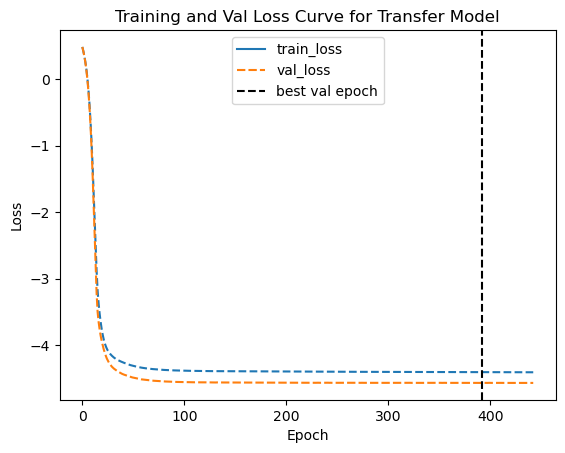

In [98]:
ax = plot_train_and_val_loss(np.array(transfer_results_ret), title="Training and Val Loss Curve for Transfer Model")

In [ ]:
# Load best pretrain model
backbone = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    feature_dropout=0.025
)

pretrain_model = MDNPretrain(
    backbone=backbone
)

pretrain_model.load_state_dict(torch.load("../results/pretrain_model.pt", map_location="cpu"))

# Full training loop
train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

transfer_model_no_ret = MDNFinalLayer(backbone, n_components=5, mean_zero=True)
    
# freeze backbone if I want
for param in transfer_model_no_ret.backbone.parameters():
    param.requires_grad = True


optimizer = torch.optim.Adam(
    [
        {"params": transfer_model_no_ret.backbone.parameters(), "lr": 1e-5},
        {"params": transfer_model_no_ret.mixture_weights.parameters(), "lr": 1e-4},
        {"params": transfer_model_no_ret.scales.parameters(), "lr": 1e-4},
    ]
)

epochs = 500
early_stopping_patience = 50

transfer_results_no_ret = []
best_val_nll = np.inf
last_improvement = 0
best_state_dict = None

print_frequency = 20

for t in range(1, epochs + 1):
    epoch_loss = train_mdn(transfer_model_no_ret, train_loader, optimizer)
    epoch_val_nll = compute_mdn_nll(transfer_model_no_ret, val_loader)
    epoch_train_nll = compute_mdn_nll(transfer_model_no_ret, train_loader)
    epoch_val_crps = compute_mean_crps_mdn(transfer_model_no_ret, val_loader)

    if epoch_val_nll < best_val_nll:
        best_val_nll = epoch_val_nll
        last_improvement = t
        best_epoch = t
        best_state_dict = copy.deepcopy(transfer_model_no_ret.state_dict())

    if t % print_frequency == 0:
        print(f"Epoch {t}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss:.2f}, training nll: {epoch_train_nll}, val nll: {epoch_val_nll}, val crps: {epoch_val_crps}\n")

    transfer_results_no_ret.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])

    if t - last_improvement >= early_stopping_patience:
        break

best_idx = max(0, last_improvement - 1)

if best_state_dict is not None:
    transfer_model_no_ret.load_state_dict(best_state_dict)

transfer_results_no_ret = np.array(transfer_results_no_ret)
val_nlls = transfer_results_no_ret[:, 2]
left = max(0, best_idx - 10)
right = min(len(val_nlls), best_idx + 3)
local_mean_val_nll = float(np.mean(val_nlls[left:right]))
print(f"Best val nll: {best_val_nll}, local mean vall nll: {local_mean_val_nll:.6f}")

Epoch 20/500
-------------------------------
Loss: -0.81, training nll: -0.8966852426528931, val nll: -0.9476830363273621, val crps: 0.038721219837163076

Epoch 40/500
-------------------------------
Loss: -3.86, training nll: -3.882819652557373, val nll: -4.070521354675293, val crps: 0.0020621997498343593

Epoch 60/500
-------------------------------
Loss: -4.21, training nll: -4.22489070892334, val nll: -4.414926528930664, val crps: 0.0017401565956857345

Epoch 80/500
-------------------------------
Loss: -4.31, training nll: -4.314021587371826, val nll: -4.498047351837158, val crps: 0.0016761840414583201

Epoch 100/500
-------------------------------
Loss: -4.34, training nll: -4.354424953460693, val nll: -4.5344390869140625, val crps: 0.001642537431464581

Epoch 120/500
-------------------------------
Loss: -4.37, training nll: -4.375227451324463, val nll: -4.550887584686279, val crps: 0.0016271740590595334

Epoch 140/500
-------------------------------
Loss: -4.38, training nll: -

In [100]:
torch.save(transfer_model_no_ret.state_dict(), "../results/transfer_model_no_ret.pt")

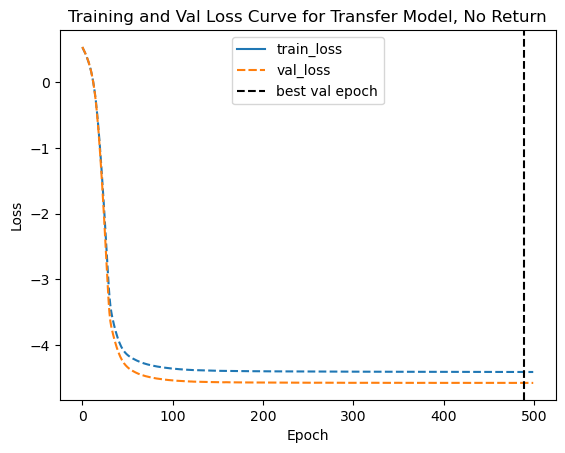

In [101]:
ax = plot_train_and_val_loss(np.array(transfer_results_no_ret), title="Training and Val Loss Curve for Transfer Model, No Return")

# Compare Models

In [329]:
backbone_ret = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    dropout=0.0,
    feature_dropout=0.05,
)

backbone_no_ret = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    dropout=0.0,
    feature_dropout=0.05,
)

transfer_model_ret = MDNFinalLayer(backbone_ret, n_components=5, mean_zero=False)
transfer_model_ret.load_state_dict(torch.load("../results/transfer_model_ret.pt", map_location="cpu"))

transfer_model_no_ret = MDNFinalLayer(backbone_no_ret, n_components=5, mean_zero=True)
transfer_model_no_ret.load_state_dict(torch.load("../results/transfer_model_no_ret.pt", map_location="cpu"))

original_model = MDN(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    n_components=5,
    hidden_layers=3,
    feature_dropout=0.1,
    mean_zero=True
)
original_model.load_state_dict(torch.load("../results/original_model.pt", map_location="cpu"))

<All keys matched successfully>

In [330]:
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

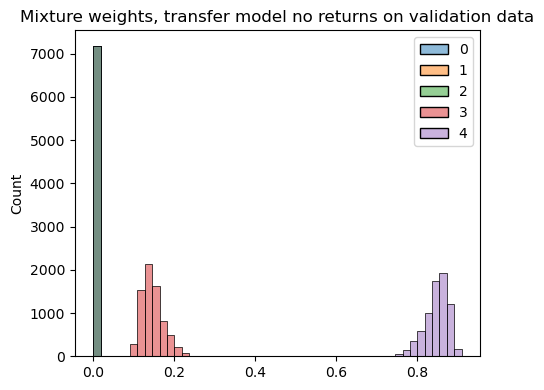

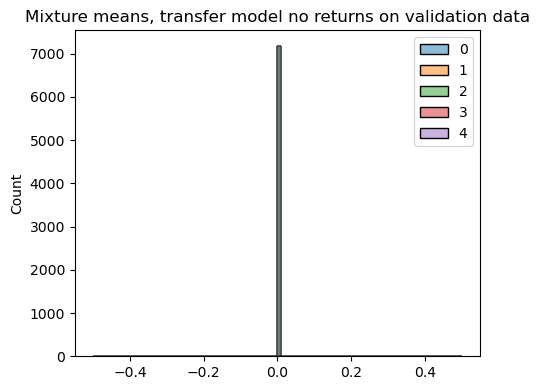

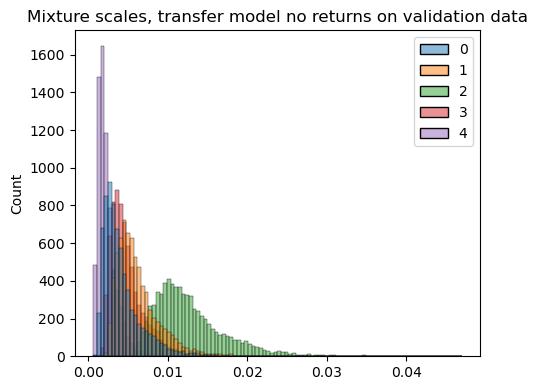

In [331]:
ax1, ax2, ax3 = plot_predicted_parameters(transfer_model_no_ret, "transfer model no returns", val_loader, "validation")

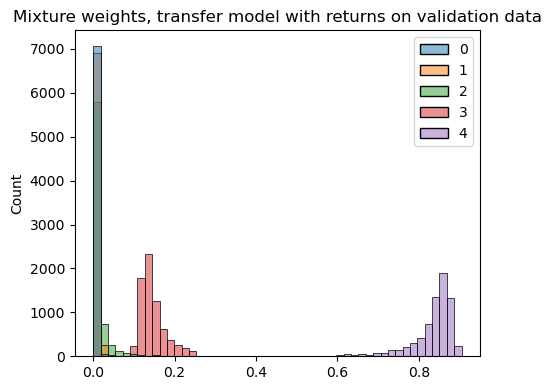

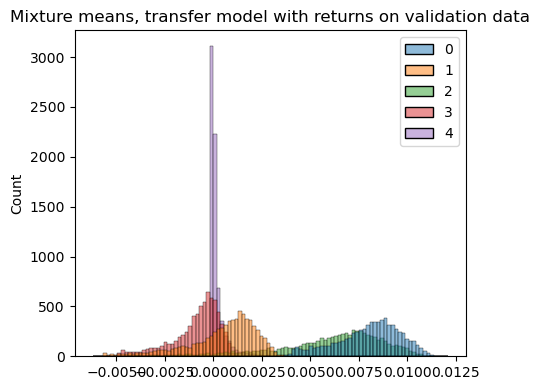

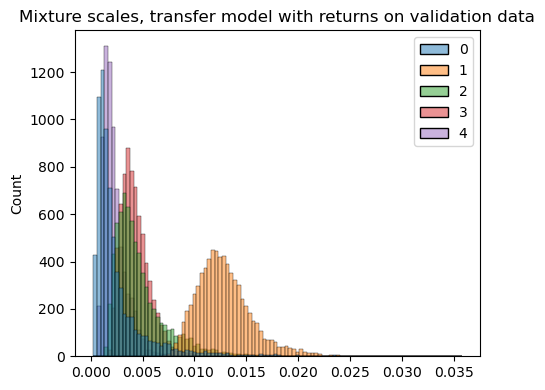

In [332]:
ax1, ax2, ax3 = plot_predicted_parameters(transfer_model_ret, "transfer model with returns", val_loader, "validation")


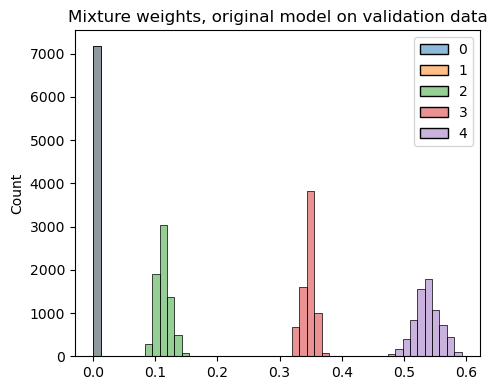

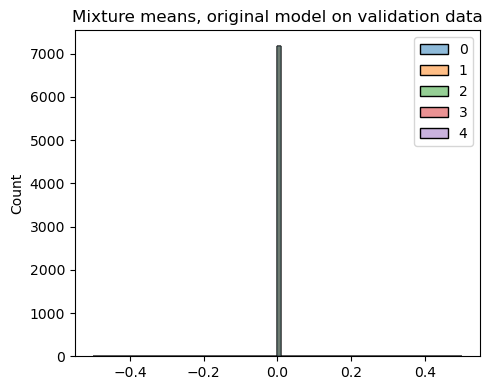

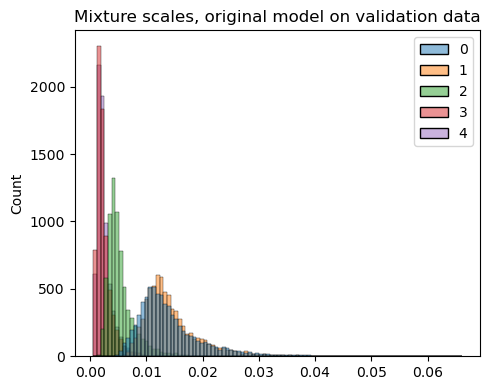

In [333]:
ax1, ax2, ax3 = plot_predicted_parameters(original_model, "original model", val_loader, "validation", save_figs=True)


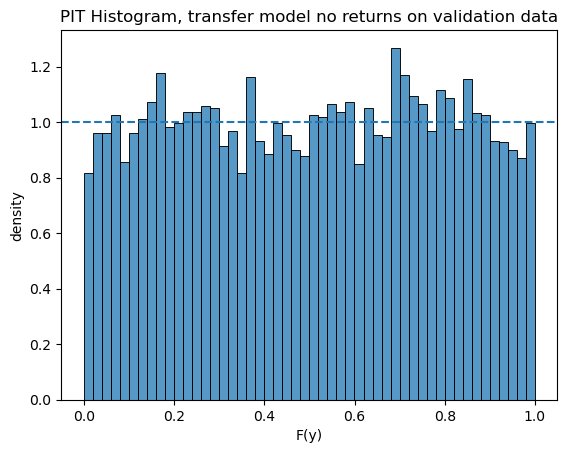

In [334]:
ax = plot_pit(transfer_model_no_ret, "transfer model no returns", val_loader, "validation")


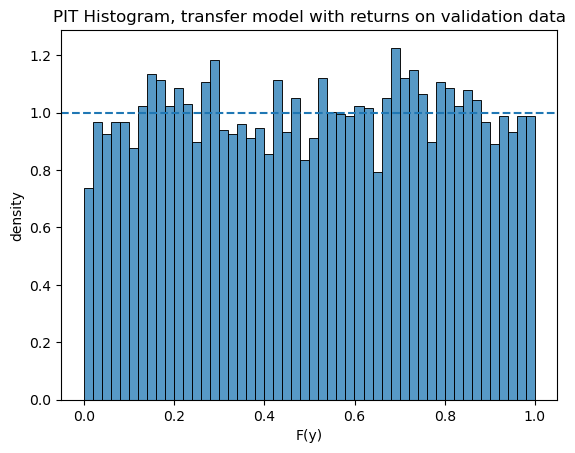

In [335]:
ax = plot_pit(transfer_model_ret, "transfer model with returns", val_loader, "validation")


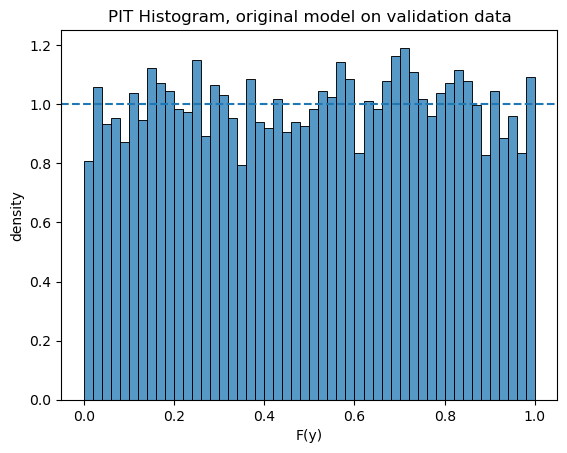

In [336]:
ax = plot_pit(original_model, "original model", val_loader, "validation")


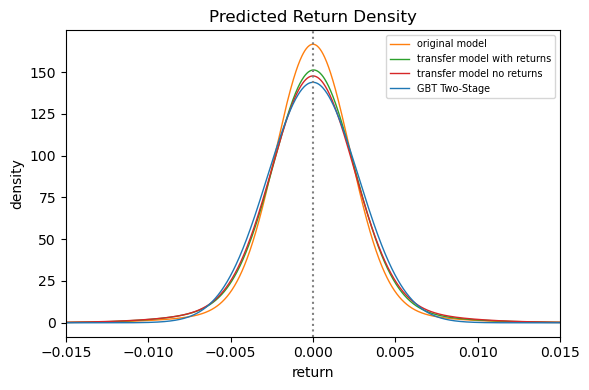

In [337]:
ax = plot_mdns_vs_gbt_vol_medoid(
    X_val,
    {"original model": original_model,
     "transfer model with returns": transfer_model_ret,
     "transfer model no returns": transfer_model_no_ret},
    df_val,
    left=-0.015,
    right=0.015,
)

### Summary Statistics

In [338]:
gbt_sigma = np.sqrt(df_test["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)

original_nll = compute_mdn_nll(original_model, test_loader)
transfer_no_ret_nll = compute_mdn_nll(transfer_model_no_ret, test_loader)
transfer_ret_nll = compute_mdn_nll(transfer_model_ret, test_loader)
gbt_nll = calculate_normal_nll(y_test.numpy(), gbt_sigma)

original_crps = compute_mean_crps_mdn(original_model, test_loader)
transfer_no_ret_crps = compute_mean_crps_mdn(transfer_model_no_ret, test_loader)
transfer_ret_crps = compute_mean_crps_mdn(transfer_model_ret, test_loader)
gbt_crps = compute_mean_crps_gaussian(y_test.numpy(), gbt_sigma)

In [339]:
results = pd.DataFrame({
    "Model": [
        "Baseline Normal (GBT Volatility)",
        "MDN (No Transfer, No Mean Prediction)",
        "MDN (Transfer, No Mean Prediction)",
        "MDN (Transfer, With Mean Prediction)"
    ],
    "NLL": [
        gbt_nll,
        original_nll,
        transfer_no_ret_nll,
        transfer_ret_nll
    ],
    "CRPS": [
        gbt_crps,
        original_crps,
        transfer_no_ret_crps,
        transfer_ret_crps
    ]
})
display(results)
# print(results.round({"NLL": 4, "CRPS": 8}).to_latex(index=False))

,Model,NLL,CRPS
0,Baseline Normal (GBT Volatility),-4.598488,0.001469
1,"MDN (No Transfer, No Mean Prediction)",-4.643855,0.001468
2,"MDN (Transfer, No Mean Prediction)",-4.644280,0.001467
3,"MDN (Transfer, With Mean Prediction)",-4.643393,0.001466


### Trading Simulation (For Fun)

In [340]:
def price_call_mixture(strike_return, mixture_probs, means, scales):
    z = (means - strike_return) / scales
    individual_prices = (means - strike_return) * stats.norm.cdf(z) + scales * stats.norm.pdf(z)
    return torch.sum(mixture_probs * individual_prices, dim=1)

def price_binary_mixture(strike_return, mixture_probs, means, scales):
    z = (means - strike_return) / scales
    individual_prices = stats.norm.cdf(z)
    return torch.sum(mixture_probs * individual_prices, dim=1)

def simulate_call_trades_mdn(strike_return, model_one, model_two, X, y, tol=1e-5):
    model_one.eval() 
    model_two.eval()
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_probs, means, scales = model_one(X)
        prices_one = price_call_mixture(strike_return, mixture_probs, means, scales)

        mixture_probs, means, scales = model_two(X)
        prices_two = price_call_mixture(strike_return, mixture_probs, means, scales)

        trade_price = 0.5 * (prices_one + prices_two)

        payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

        return ((prices_one - prices_two) * (payoff - trade_price)).numpy()
    
def simulate_binary_trades_mdn(strike_return, model_one, model_two, X, y, tol=1e-5):
    model_one.eval() 
    model_two.eval()
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_probs, means, scales = model_one(X)
        prices_one = price_binary_mixture(strike_return, mixture_probs, means, scales)

        mixture_probs, means, scales = model_two(X)
        prices_two = price_binary_mixture(strike_return, mixture_probs, means, scales)

        trade_price = 0.5 * (prices_one + prices_two)

        payoff = torch.where(y > strike_return, 1, 0)

        return ((prices_one - prices_two) * (payoff - trade_price)).numpy()
    

def price_call_normal(sigma: float, strike_return: float, mu: float = 0.0):
    z = (mu - strike_return) / sigma
    return np.where(sigma > 0, (mu - strike_return) * stats.norm.cdf(z) + sigma * stats.norm.pdf(z), max(mu - strike_return, 0.0))

def price_binary_normal(sigma: float, strike_return: float, mu: float = 0.0):
    z = (mu - strike_return) / sigma
    return np.where(sigma > 0, stats.norm.cdf(z), np.where(mu - strike_return > 0, 1, 0))


def simulate_call_trades_mdn_vs_gbt(strike_return, model, X, y, df, tol=1e-5):
    pnls = []

    model.eval() 
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_probs, means, scales = model(X)
        prices_mdn = price_call_mixture(strike_return, mixture_probs, means, scales)

        gbt_sigma = np.sqrt(df["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)
        prices_gbt = torch.tensor(price_call_normal(gbt_sigma, strike_return))

        trade_price = 0.5 * (prices_mdn + prices_gbt)

        payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

        size = torch.abs(prices_mdn - prices_gbt)

        direction = torch.where(torch.abs(prices_mdn - prices_gbt) < tol, 0, torch.where(prices_mdn < prices_gbt, -1, 1))

        pnls.append(size * direction * (payoff - trade_price))


    return torch.cat(pnls).numpy()

def simulate_binary_trades_mdn_vs_gbt(strike_return, model, X, y, df, tol=1e-5):
    pnls = []

    model.eval() 
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_probs, means, scales = model(X)
        prices_mdn = price_binary_mixture(strike_return, mixture_probs, means, scales)

        gbt_sigma = np.sqrt(df["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)
        prices_gbt = torch.tensor(price_binary_normal(gbt_sigma, strike_return))

        trade_price = 0.5 * (prices_mdn + prices_gbt)

        payoff = torch.where(y > strike_return, 1, 0)

        direction = torch.where(torch.abs(prices_mdn - prices_gbt) < tol, 0, torch.where(prices_mdn < prices_gbt, -1, 1))

        pnls.append(direction * (payoff - trade_price))


    return torch.cat(pnls).numpy()

def compute_pricing_error_mdn(strike_return, model, X, y):
    errors = []

    model.eval() 
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_probs, means, scales = model(X)
        prices_mdn = price_call_mixture(strike_return, mixture_probs, means, scales)

        payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

        error = payoff - prices_mdn

        errors.append(error)


    return torch.cat(errors).numpy()

def compute_pricing_error_gbt(strike_return, y, df):
    errors = []

    gbt_sigma = np.sqrt(df["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)
    prices_gbt = torch.tensor(price_call_normal(gbt_sigma, strike_return))

    payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

    error = payoff - prices_gbt

    errors.append(error)


    return torch.cat(errors).numpy()

# def simulate_call_trades_mdn_vs_gbt(strike_return, model, model_two, data_loader, df):
#     pnls = []

#     model_one.eval() 
#     model_two.eval()
#     with torch.no_grad():
#         for (X, y) in data_loader:
#             X, y = X.to(device), y.to(device)
            
#             mixture_weights, means, scales = model_one(X)
#             mixture_probs = F.softmax(mixture_weights, dim=1)
#             prices_one = price_call_mixture(strike_return, mixture_probs, means, scales)

#             mixture_weights, means, scales = model_two(X)
#             mixture_probs = F.softmax(mixture_weights, dim=1)
#             prices_two = price_call_mixture(strike_return, mixture_probs, means, scales)

#             trade_price = 0.5 * (prices_one + prices_two)

#             payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

#             direction = torch.where(prices_one < prices_two, -1, 1)

#             pnls.append(direction * (payoff - trade_price))


#     return torch.cat(pnls).numpy()

def calculate_t_stat_from_pnl(pnls: np.ndarray) -> float:
    grouped = pd.Series(pnls).groupby(np.arange(len(pnls)) // 48).sum()
    grouped = grouped[grouped != 0]
    return grouped.sum() / np.sqrt((grouped ** 2).sum())


def calculate_t_stats_call(strike_return: float, models: dict[str, nn.Module], X: torch.Tensor, y: torch.Tensor,
                             df: pd.DataFrame, tol: float = 1e-5) -> pd.DataFrame:
    model_names = list(models.keys())
    num_models = len(model_names)
    matrix = np.zeros(shape=(1 + num_models, 1 + num_models))
    for i in range(num_models):
        name = model_names[i]
        pnls = simulate_call_trades_mdn_vs_gbt(strike_return, models[name], X, y, df, tol=tol)
        t = calculate_t_stat_from_pnl(pnls)
        matrix[num_models][i] = -t
        matrix[i][num_models] = t
    
    for i in range(num_models):
        name_one = model_names[i]
        for j in range(i, num_models):
            name_two = model_names[j]
            pnls = simulate_call_trades_mdn(strike_return, models[name_one], models[name_two], X, y, tol=tol)
            t = calculate_t_stat_from_pnl(pnls)
            matrix[i][j] = t
            matrix[j][i] = -t

    index = model_names + ["GBT Two-Stage"]
    return pd.DataFrame(matrix, index=index, columns=index)

def calculate_t_stats_binary(strike_return: float, models: dict[str, nn.Module], X: torch.Tensor, y: torch.Tensor,
                             df: pd.DataFrame, tol: float = 1e-5) -> pd.DataFrame:
    model_names = list(models.keys())
    num_models = len(model_names)
    matrix = np.zeros(shape=(1 + num_models, 1 + num_models))
    for i in range(num_models):
        name = model_names[i]
        pnls = simulate_binary_trades_mdn_vs_gbt(strike_return, models[name], X, y, df, tol=tol)
        t = calculate_t_stat_from_pnl(pnls)
        matrix[num_models][i] = -t
        matrix[i][num_models] = t
    
    for i in range(num_models):
        name_one = model_names[i]
        for j in range(i, num_models):
            name_two = model_names[j]
            pnls = simulate_binary_trades_mdn(strike_return, models[name_one], models[name_two], X, y, tol=tol)
            t = calculate_t_stat_from_pnl(pnls)
            matrix[i][j] = t
            matrix[j][i] = -t

    index = model_names + ["GBT Two-Stage"]
    return pd.DataFrame(matrix, index=index, columns=index)

    
    


In [341]:
models = {"original model": original_model,
     "transfer model with returns": transfer_model_ret,
     "transfer model no returns": transfer_model_no_ret}

calculate_t_stats_call(0.001, models, X_val, y_val, df_val)
                           

/var/folders/p5/43mbl8f524l84p63s3mcyvxw0000gn/T/ipykernel_58613/301997740.py:172: RuntimeWarning: invalid value encountered in scalar divide
  return grouped.sum() / np.sqrt((grouped ** 2).sum())


,original model,transfer model with returns,transfer model no returns,GBT Two-Stage
original model,NaN,-0.886902,-1.666423,-0.323574
transfer model with returns,0.886902,NaN,-0.110032,1.191876
transfer model no returns,1.666423,0.110032,NaN,0.840890
GBT Two-Stage,0.323574,-1.191876,-0.840890,0.000000


-1.5020722580063723

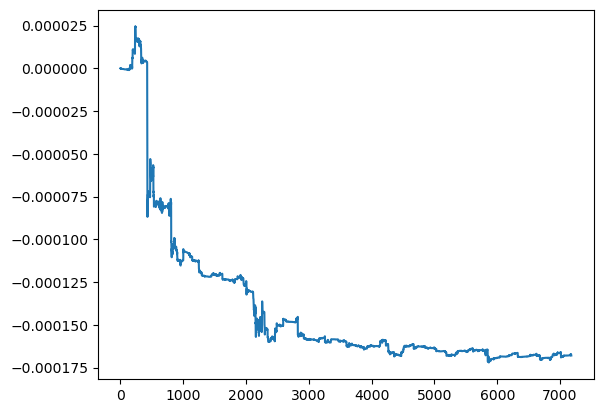

In [317]:
pnls = simulate_call_trades_mdn(0.001, original_model, transfer_model_ret, X_val, y_val)
sns.lineplot(np.cumsum(pnls))
calculate_t_stat_from_pnl(pnls)

<Axes: >

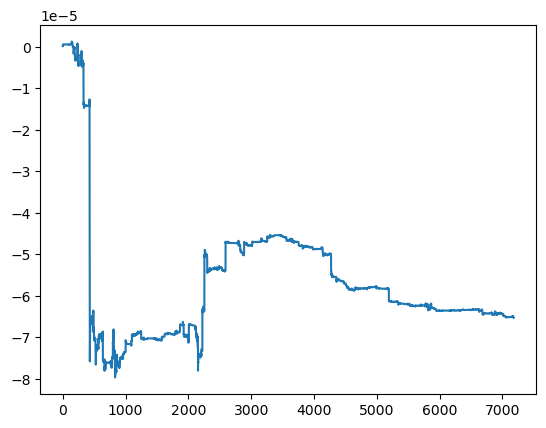

In [318]:
pnls = simulate_call_trades_mdn(0.001, transfer_model_no_ret, transfer_model_ret, X_val, y_val)
sns.lineplot(np.cumsum(pnls))

-0.3235739601342912

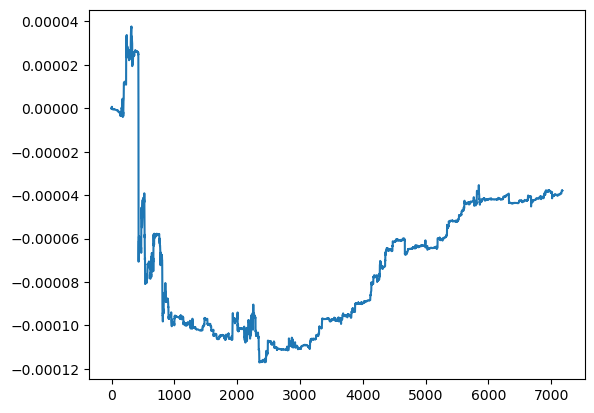

In [319]:
pnls = simulate_call_trades_mdn_vs_gbt(0.001, original_model, X_val, y_val, df_val)
sns.lineplot(np.cumsum(pnls))
calculate_t_stat_from_pnl(pnls)

2.873768440414387

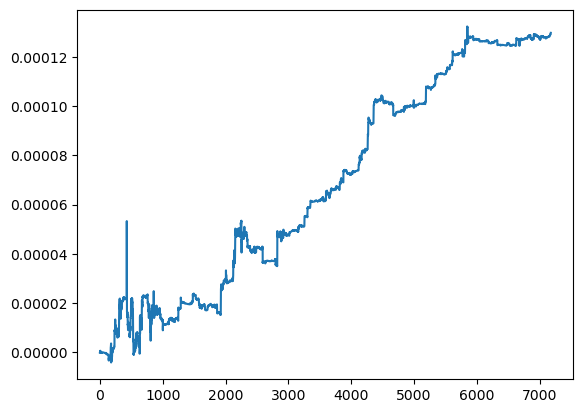

In [320]:
pnls = simulate_call_trades_mdn_vs_gbt(0.001, transfer_model_ret, X_val, y_val, df_val)
sns.lineplot(np.cumsum(pnls))
calculate_t_stat_from_pnl(pnls)

-0.3235739601342912

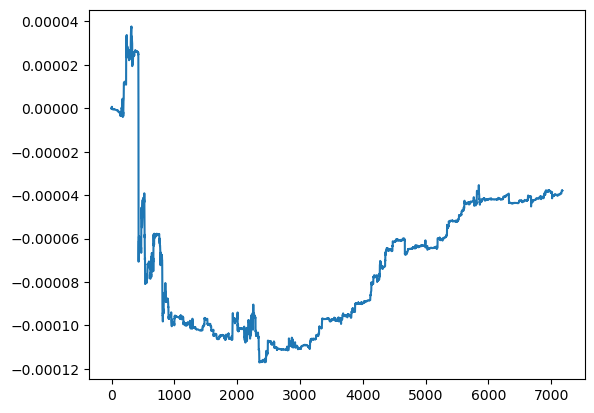

In [321]:
pnls = simulate_call_trades_mdn_vs_gbt(0.001, original_model, X_val, y_val, df_val)
sns.lineplot(np.cumsum(pnls))
calculate_t_stat_from_pnl(pnls)

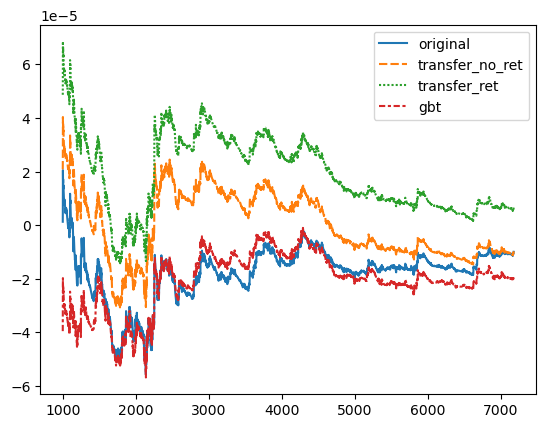

In [293]:
def plot_average_error(errors: dict, min_points):
    df = pd.DataFrame({col: np.cumsum(error) / np.cumsum(np.ones_like(error)) for col, error in errors.items()})
    sns.lineplot(df[min_points:])

error_original = compute_pricing_error_mdn(0.001, original_model, X_val, y_val)
error_transfer_no_ret = compute_pricing_error_mdn(0.001, transfer_model_no_ret, X_val, y_val)
error_transfer_ret = compute_pricing_error_mdn(0.001, transfer_model_ret, X_val, y_val)
error_gbt = compute_pricing_error_gbt(0.001, y_val, df_val)
plot_average_error({"original": error_original, "transfer_no_ret": error_transfer_no_ret,
                    "transfer_ret": error_transfer_ret, "gbt": error_gbt}, 
                    1000)

0.8792353142029242

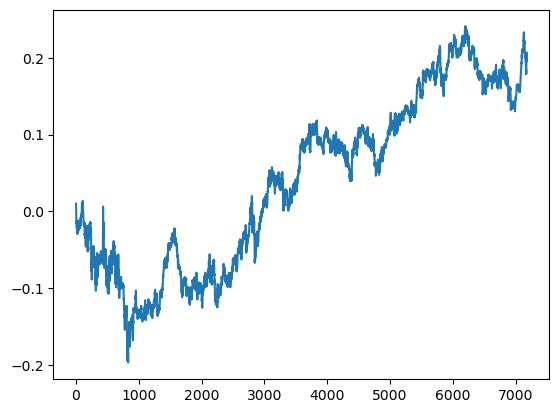

In [322]:
pnls = simulate_binary_trades_mdn(0.001, transfer_model_ret, transfer_model_no_ret, X_val, y_val, tol=1e-5)
sns.lineplot(np.cumsum(pnls))
calculate_t_stat_from_pnl(pnls)

0.2154912131098193

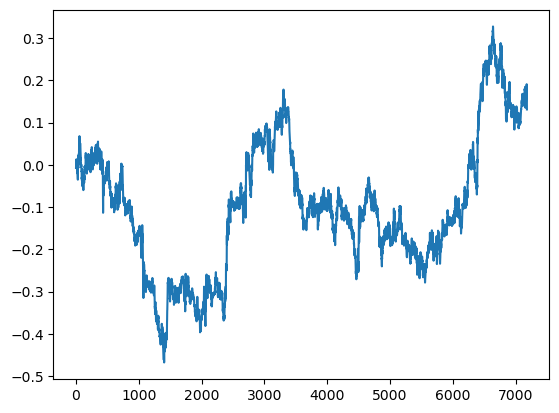

In [323]:
pnls = simulate_binary_trades_mdn(0.001, original_model, transfer_model_ret, X_val, y_val, tol=1e-5)
sns.lineplot(np.cumsum(pnls))
calculate_t_stat_from_pnl(pnls)

-0.021004071279825814

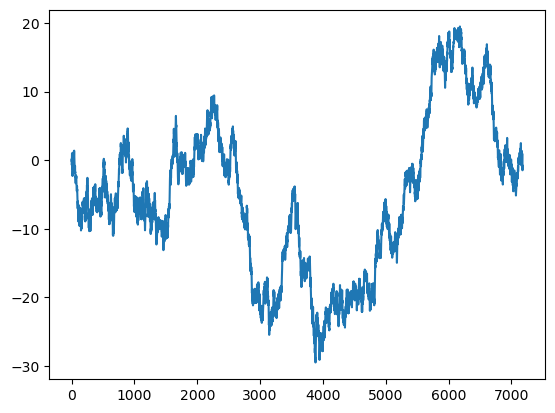

In [296]:
pnls = simulate_binary_trades_mdn_vs_gbt(0.001, transfer_model_ret, X_val, y_val, df_val)
sns.lineplot(np.cumsum(pnls))
calculate_t_stat_from_pnl(pnls)

In [153]:
def compute_prob_up_mdn(model, X, y):
    model.eval() 
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_weights, means, scales = model(X)
        mixture_probs = F.softmax(mixture_weights, dim=1)
        p_below = price_binary_mixture(0.0, mixture_probs, means, scales)

        return p_below
    

In [175]:
torch.quantile(compute_prob_up_mdn(transfer_model_no_ret, X_val, y_val), 0.1)

tensor(0.5000, dtype=torch.float64)

In [356]:
df_val["pred_p_up"] = compute_prob_up_mdn(transfer_model_ret, X_val, y_val)

In [357]:
df_val["pred_p_up"].describe()

count    7179.000000
mean        0.625311
std         0.047476
min         0.385486
25%         0.610378
50%         0.642744
75%         0.657421
max         0.696530
Name: pred_p_up, dtype: float64

<Axes: ylabel='pred_p_up'>

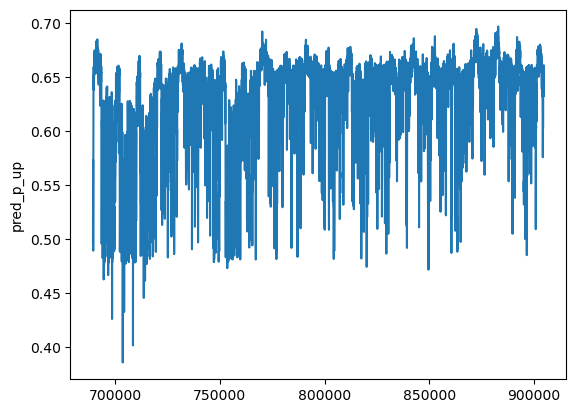

In [358]:
sns.lineplot(df_val["pred_p_up"])

In [359]:
df_val["up"] = np.where(df_val["future_30m_ret"] > 0, 1, 0)

<Axes: xlabel='pred_p_up', ylabel='Count'>

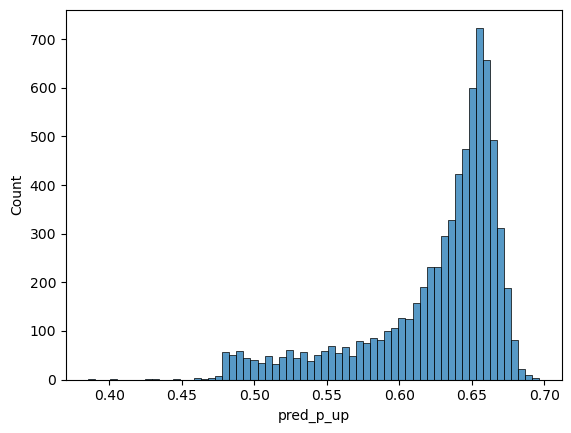

In [360]:
sns.histplot(df_val["pred_p_up"])

In [303]:
df_val.query("pred_p_up > 0.43 and pred_p_up < 0.45")[["pred_p_up", "up"]].describe()

,pred_p_up,up
count,891.000000,891.000000
mean,0.442983,0.505051
std,0.004000,0.500255
min,0.430597,0.000000
25%,0.440114,0.000000
50%,0.443007,1.000000
75%,0.446076,1.000000
max,0.449989,1.000000


In [126]:
df_val.query("pred_p_up > 0.43 and pred_p_up < 0.45")

,split,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,...,future_15m_mean_sq_ret,future_30m_mean_sq_ret,future_30m_neutral_up_down,past_5m_abs_ret,past_30m_abs_ret,past_60m_abs_ret,past_120m_abs_ret,day_of_week,pred_p_up,up
704280,val,2025-03-03 21:00:00 ET,83380.72,83428.92,83177.51,83419.01,72.97084,2025-03-03 21:00:59 ET,6.079754e+06,16011,...,0.000010,0.000007,0,0.003516,0.027154,0.030980,0.032944,0,0.432203,0
713670,val,2025-03-10 10:30:00 ET,79882.36,80176.79,79839.90,80133.22,76.09220,2025-03-10 10:30:59 ET,6.083797e+06,11891,...,0.000005,0.000004,1,0.005394,0.020196,0.033724,0.035532,0,0.445255,0


(-25566.333333333332, -25566.125)

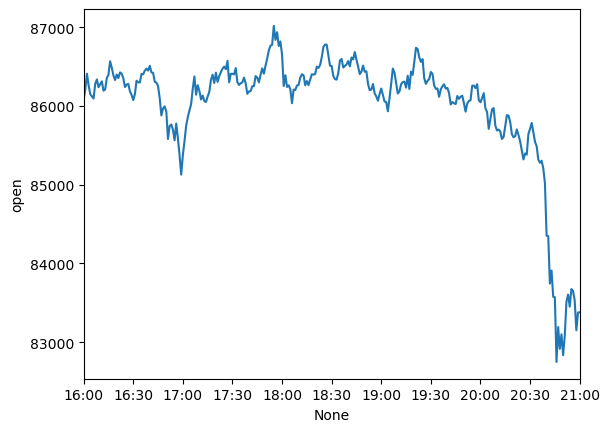

In [129]:
import matplotlib.dates as mdates

to_plot = df[(df["open_time"] <= "2025-03-03 21:00:00 ET") & (df["open_time"] >= "2025-03-03 16:00:00 ET")]

time = pd.to_datetime(
    to_plot["hour"].astype(str) + ":" + to_plot["minute"].astype(str),
    format="%H:%M"
)


ax = sns.lineplot(x=time, y=to_plot["open"])

ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlim(time.iloc[0], time.iloc[-1])

### Experiments with Joint Loss and Ensemble

In [ ]:
# Load best pretrain model
backbone = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    feature_dropout=0.025
)

pretrain_model = MDNPretrain(
    backbone=backbone
)

pretrain_model.load_state_dict(torch.load("../results/pretrain_model.pt", map_location="cpu"))

# Full training loop
train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

transfer_model_ret = MDNFinalLayer(backbone, n_components=5, mean_zero=False)

if transfer_model_ret.means is not None:
    # Initialize mean weights to 0
    torch.nn.init.zeros_(transfer_model_ret.means.weight)
    torch.nn.init.zeros_(transfer_model_ret.means.bias)
        
    # freeze backbone if I want
    for param in transfer_model_ret.backbone.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam(
        [
            {"params": transfer_model_ret.backbone.parameters(), "lr": 1e-5},
            {"params": transfer_model_ret.mixture_weights.parameters(), "lr": 1e-4},
            {"params": transfer_model_ret.scales.parameters(), "lr": 1e-4},
            {"params": transfer_model_ret.means.parameters(), "lr": 1e-6},
        ]
    )

else:
    # Only exists to make pylint happy
    optimizer = torch.optim.Adam(transfer_model_ret.parameters(), lr=1e-5)

epochs = 500
early_stopping_patience = 50

transfer_results_ret = []
best_val_nll = np.inf
last_improvement = 0
best_state_dict = None

print_frequency = 20

for t in range(1, epochs + 1):
    epoch_loss = train_mdn(transfer_model_ret, train_loader, optimizer)
    epoch_val_nll = compute_mdn_nll(transfer_model_ret, val_loader)
    epoch_train_nll = compute_mdn_nll(transfer_model_ret, train_loader)
    epoch_val_crps = compute_mean_crps_mdn(transfer_model_ret, val_loader)

    if epoch_val_nll < best_val_nll:
        best_val_nll = epoch_val_nll
        last_improvement = t
        best_epoch = t
        best_state_dict = copy.deepcopy(transfer_model_ret.state_dict())

    if t % print_frequency == 0:
        print(f"Epoch {t}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss:.6f}, training nll: {epoch_train_nll}, val nll: {epoch_val_nll}, val crps: {epoch_val_crps}\n")

    transfer_results_ret.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
    
    if t - last_improvement >= early_stopping_patience:
        break

best_val_loss = np.inf
crps_weight = 0.5
print_frequency = 20
best_val_loss = np.inf
start_epoch = len(transfer_results_ret)

for t in range(start_epoch + 1, start_epoch + epochs + 1):
    epoch_loss = train_mdn_crps_and_nll(transfer_model_ret, train_loader, optimizer, crps_weight=crps_weight)
    epoch_val_nll = compute_mdn_nll(transfer_model_ret, val_loader)
    epoch_train_nll = compute_mdn_nll(transfer_model_ret, train_loader)
    epoch_val_crps = compute_mean_crps_mdn(transfer_model_ret, val_loader)
    epoch_val_loss = (crps_weight) * 1000 * epoch_val_crps + (1 - crps_weight) * epoch_val_nll

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        last_improvement = t
        best_epoch = t
        best_state_dict = copy.deepcopy(transfer_model_ret.state_dict())

    if t % print_frequency == 0:
        print(f"Epoch {t}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss:.6f}, val loss: {epoch_val_loss}, training nll: {epoch_train_nll}, val nll: {epoch_val_nll}, val crps: {epoch_val_crps}\n")

    transfer_results_ret.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
    
    if t - last_improvement >= early_stopping_patience:
        break


best_idx = max(0, last_improvement - 1)

if best_state_dict is not None:
    transfer_model_ret.load_state_dict(best_state_dict)

transfer_results_ret = np.array(transfer_results_ret)
val_nlls = transfer_results_ret[:, 2]
left = max(0, best_idx - 10)
right = min(len(val_nlls), best_idx + 3)
local_mean_val_nll = float(np.mean(val_nlls[left:right]))
print(f"Best val nll: {best_val_nll}, local mean vall nll: {local_mean_val_nll:.6f}, ")

Epoch 20/500
-------------------------------
Loss: -4.310344, training nll: -4.325545787811279, val nll: -4.514566898345947, val crps: 0.001659147749105355

Epoch 40/500
-------------------------------
Loss: -4.372475, training nll: -4.383236408233643, val nll: -4.561445236206055, val crps: 0.0016166528003525367

Epoch 60/500
-------------------------------
Loss: -4.386612, training nll: -4.3965959548950195, val nll: -4.569277763366699, val crps: 0.0016101869521937676

Epoch 80/500
-------------------------------
Loss: -4.393860, training nll: -4.4015936851501465, val nll: -4.571400165557861, val crps: 0.0016088134159773844

Epoch 100/500
-------------------------------
Loss: -4.397257, training nll: -4.404332637786865, val nll: -4.57268762588501, val crps: 0.0016080461397029204

Epoch 120/500
-------------------------------
Loss: -4.398051, training nll: -4.405650615692139, val nll: -4.572131633758545, val crps: 0.0016079021286122687

Epoch 140/500
-------------------------------
Loss

In [342]:
class MDNEnsemble(nn.Module):
    def __init__(self, models):
        super().__init__()
        self.models = nn.ModuleList(models)

    def forward(self, x):
        probs_list = []
        means_list = []
        scales_list = []

        for model in self.models:
            probs, means, scales = model(x)
            probs_list.append(probs / len(self.models))
            means_list.append(means)
            scales_list.append(scales)

        probs = torch.cat(probs_list, dim=1)
        means = torch.cat(means_list, dim=1)
        scales = torch.cat(scales_list, dim=1)

        return probs, means, scales

In [343]:
ensemble_model = MDNEnsemble([
    original_model,
    transfer_model_ret,
    transfer_model_no_ret
])

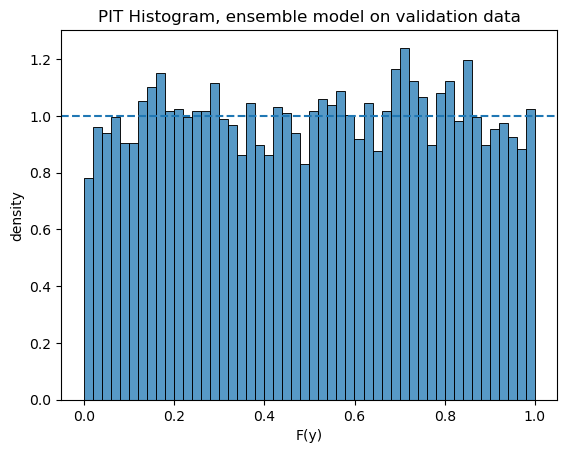

In [344]:
ax = plot_pit(ensemble_model, "ensemble model", val_loader, "validation")


In [347]:
gbt_sigma = np.sqrt(df_test["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)

original_nll = compute_mdn_nll(original_model, test_loader)
transfer_no_ret_nll = compute_mdn_nll(transfer_model_no_ret, test_loader)
transfer_ret_nll = compute_mdn_nll(transfer_model_ret, test_loader)
ensemble_nll = compute_mdn_nll(ensemble_model, test_loader)
gbt_nll = calculate_normal_nll(y_test.numpy(), gbt_sigma)

original_crps = compute_mean_crps_mdn(original_model, test_loader)
transfer_no_ret_crps = compute_mean_crps_mdn(transfer_model_no_ret, test_loader)
transfer_ret_crps = compute_mean_crps_mdn(transfer_model_ret, test_loader)
ensemble_crps = compute_mean_crps_mdn(ensemble_model, test_loader)
gbt_crps = compute_mean_crps_gaussian(y_test.numpy(), gbt_sigma)

In [348]:
results = pd.DataFrame({
    "Model": [
        "Baseline Normal (GBT Volatility)",
        "MDN (No Transfer, No Mean Prediction)",
        "MDN (Transfer, No Mean Prediction)",
        "MDN (Transfer, With Mean Prediction)",
        "Ensemble"
    ],
    "NLL": [
        gbt_nll,
        original_nll,
        transfer_no_ret_nll,
        transfer_ret_nll,
        ensemble_nll
    ],
    "CRPS": [
        gbt_crps,
        original_crps,
        transfer_no_ret_crps,
        transfer_ret_crps,
        ensemble_crps
    ]
})
display(results)
# print(results.round({"NLL": 4, "CRPS": 8}).to_latex(index=False))

,Model,NLL,CRPS
0,Baseline Normal (GBT Volatility),-4.598488,0.001469
1,"MDN (No Transfer, No Mean Prediction)",-4.643855,0.001468
2,"MDN (Transfer, No Mean Prediction)",-4.644280,0.001467
3,"MDN (Transfer, With Mean Prediction)",-4.643393,0.001466
4,Ensemble,-4.646855,0.001466


In [353]:
models = {"original model": original_model,
     "transfer model with returns": transfer_model_ret,
     "transfer model no returns": transfer_model_no_ret,
     "ensemble": ensemble_model}

calculate_t_stats_binary(0.001, models, X_val, y_val, df_val)
                           

/var/folders/p5/43mbl8f524l84p63s3mcyvxw0000gn/T/ipykernel_58613/301997740.py:172: RuntimeWarning: invalid value encountered in scalar divide
  return grouped.sum() / np.sqrt((grouped ** 2).sum())


,original model,transfer model with returns,transfer model no returns,ensemble,GBT Two-Stage
original model,NaN,-0.518600,0.565382,-0.899009,-0.242149
transfer model with returns,0.518600,NaN,1.520378,0.045407,0.748960
transfer model no returns,-0.565382,-1.520378,NaN,-2.792477,0.197608
ensemble,0.899009,-0.045407,2.792477,NaN,0.933400
GBT Two-Stage,0.242149,-0.748960,-0.197608,-0.933400,0.000000
